In [1]:
import timm 
import os 
import pandas as pd 

c:\Users\tijnv\Documents\Data Science and Artificial Intelligence\Jaar 2\Master Thesis\Feasibility Study\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# First filter the results.csv based on the sampled flickr images
df = pd.read_csv("./data/results.csv", delimiter="|")

def filter_results_csv(images_folder_path, results_df):
    """

    """
    images = []
    for _, _, files in os.walk(images_folder_path):
        for file in files:
            if file.endswith(".jpg"):
                images.append(file)

    results_df = results_df[results_df["image_name"].isin(images)]
    
    return results_df.reset_index(drop=True)

In [4]:
filtered_df = filter_results_csv("./data/flickr_sample/", df)

In [5]:
import tiktoken

# The following tokenizer is used in models like GPT4
enc = tiktoken.get_encoding("cl100k_base")

encoded_comments = [enc.encode(x) for x in list(filtered_df[' comment'])]
# decoded_comments = [enc.decode(x) for x in encoded_comments]

In [6]:
filtered_df['encoded_comment'] = encoded_comments
filtered_df[' comment_number'] = filtered_df[' comment_number'].astype(int)
df_sample = filtered_df[filtered_df[' comment_number'] < 2]
df_sample.head()

,image_name,comment_number,comment,encoded_comment
0,86486817.jpg,0,A man is vacuuming the rug in a child 's room...,"[362, 893, 374, 29302, 287, 279, 29742, 304, 2..."
1,86486817.jpg,1,A man is vacuuming a carpet while a toddler i...,"[362, 893, 374, 29302, 287, 264, 28954, 1418, ..."
5,86497011.jpg,0,A young boy is beginning to shoot a basketbal...,"[362, 3995, 8334, 374, 7314, 311, 6230, 264, 1..."
6,86497011.jpg,1,"A young boy in a red jersey jumps , about to ...","[362, 3995, 8334, 304, 264, 2579, 37212, 35308..."
10,86542183.jpg,0,Two children are playing ice hockey on frozen...,"[9220, 2911, 527, 5737, 10054, 28051, 389, 202..."


In [6]:
# !pip install git+https://github.com/huggingface/transformers.git@main

In [7]:
from PIL import Image
import os
import numpy as np

folder_path = './data/flickr_sample/'

images = {}
images_numpy = {}

for filename in os.listdir(folder_path):
    if filename.endswith(".jpg"):
        images[filename] = Image.open(folder_path + filename)
        images_numpy[filename] = np.array(images[filename])

In [8]:
from torch.utils.data import Dataset, DataLoader

class ImageCaptioningDataset(Dataset):
    def __init__(self, dataset, processor):
        self.dataset = dataset
        self.processor = processor

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        item = self.dataset[idx]
        encoding = self.processor(images=item["image"], text=item["text"], padding="max_length", return_tensors="pt")
        # remove batch dimension
        encoding = {k:v.squeeze() for k,v in encoding.items()}
        return encoding

In [9]:
from transformers import GPT2TokenizerFast, ViTImageProcessor, VisionEncoderDecoderModel

model = VisionEncoderDecoderModel.from_pretrained("nlpconnect/vit-gpt2-image-captioning")

# tokenizer = GPT2TokenizerFast.from_pretrained("nlpconnect/vit-gpt2-image-captioning")

image_processor, _ = ViTImageProcessor.from_pretrained("nlpconnect/vit-gpt2-image-captioning", return_unused_kwargs=True)

In [10]:
image = images['86486817.jpg']
pixel_values = image_processor(image, return_tensors='pt').pixel_values

In [11]:
encoded_images = [(name, image_processor(image, return_tensors="pt").pixel_values) for name, image in list(images.items())]

In [12]:
encoded_images

[('86486817.jpg',
  tensor([[[[ 0.4275,  0.4196,  0.4118,  ..., -0.6000, -0.5765, -0.6863],
            [ 0.4118,  0.4039,  0.3961,  ..., -0.6941, -0.6863, -0.7020],
            [ 0.3961,  0.3961,  0.4039,  ..., -0.7569, -0.7255, -0.7490],
            ...,
            [ 0.1216,  0.0824,  0.1059,  ...,  0.2392,  0.2078, -0.3176],
            [ 0.0275,  0.0510, -0.0039,  ..., -0.0431,  0.0039, -0.0588],
            [-0.0667, -0.0510, -0.0745,  ...,  0.2392,  0.1843,  0.1765]],
  
           [[ 0.2549,  0.2627,  0.2627,  ..., -0.7647, -0.7098, -0.7882],
            [ 0.2549,  0.2627,  0.2549,  ..., -0.7647, -0.7412, -0.8039],
            [ 0.2706,  0.2706,  0.2784,  ..., -0.7725, -0.7255, -0.7961],
            ...,
            [ 0.1059,  0.0588,  0.0510,  ...,  0.0902,  0.0980, -0.3647],
            [ 0.0039, -0.0039, -0.0588,  ..., -0.1451, -0.0902, -0.1608],
            [-0.0588, -0.0902, -0.1137,  ...,  0.1216,  0.0902,  0.0824]],
  
           [[ 0.1843,  0.1765,  0.1922,  ..., -0.803

In [13]:
import torchvision.transforms as transforms

# Assuming pixel_values is a PyTorch tensor
# Convert tensor to PIL image
to_pil = transforms.ToPILImage()

image_attention = to_pil(pixel_values[0])

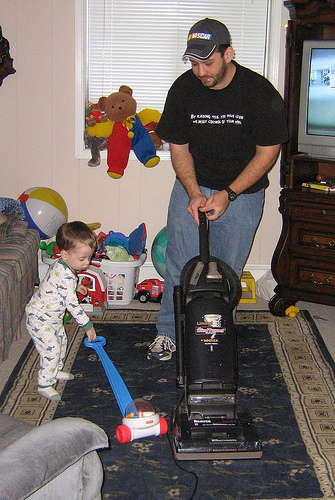

In [14]:
image

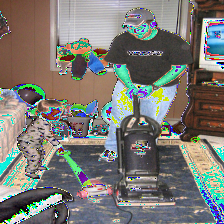

In [15]:
image_attention

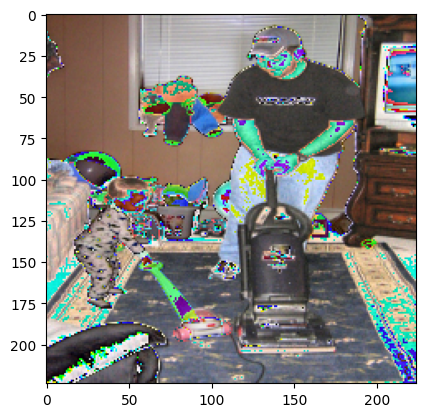

In [16]:
import matplotlib.pyplot as plt

pixel_values_numpy = np.transpose(pixel_values[0].numpy(), (1, 2, 0))

pixel_values_numpy = (pixel_values_numpy * 255).astype(np.uint8)

plt.imshow(pixel_values_numpy);

In [17]:
import torch

In [18]:
print(torch.cuda.is_available())

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

True


In [19]:
# tiktoken cl100k_base (gpt4 tokenizer)

In [19]:
from transformers import Blip2Processor, Blip2ForConditionalGeneration

In [21]:
processor = Blip2Processor.from_pretrained("Salesforce/blip2-opt-2.7b")
model = Blip2ForConditionalGeneration.from_pretrained("Salesforce/blip2-opt-2.7b", torch_dtype=torch.float16, device_map="auto")

Loading checkpoint shards: 100%|██████████| 2/2 [00:26<00:00, 13.36s/it]


In [22]:
question = "How many dogs are there in the image?"

inputs = processor(Image.open("./data/flickr_sample/86486817.jpg").convert("RGB"), question, return_tensors="pt").to(device, torch.float16)

out = model.generate(**inputs)
print(processor.decode(out[0], skip_special_tokens=True).strip())